# Import one .slp file for analysis

In [12]:
# Import .slp files to convert to h5 files

import h5py
import numpy as np

filename = 'C://Users/esay/data/social_interaction/SLEAP_raw/videos/test-0058-1/test2_degree_15.analysis.h5'
with h5py.File(filename, "r") as f:
    dset_names = list(f.keys())
    locations = f["tracks"][:].T
    node_names = [n.decode() for n in f["node_names"][:]]

print("===filename===")
print(filename)
print()

print("===HDF5 datasets===")
print(dset_names)
print()

print("===locations data shape===")
print(locations.shape)
print()

print("===nodes===")
for i, name in enumerate(node_names):
    print(f"{i}: {name}")
print()


===filename===
C://Users/esay/data/social_interaction/SLEAP_raw/videos/test-0058-1/test2_degree_15.analysis.h5

===HDF5 datasets===
['edge_inds', 'edge_names', 'instance_scores', 'labels_path', 'node_names', 'point_scores', 'provenance', 'track_names', 'track_occupancy', 'tracking_scores', 'tracks', 'video_ind', 'video_path']

===locations data shape===
(15047, 6, 2, 1)

===nodes===
0: rightear
1: tailbase
2: nose
3: head
4: leftear
5: torso



# Import dir of .slp files

In [54]:
# Modified to apply to whole directory of h5 files
import h5py
import os
import numpy as np

def process_h5_files(directory):
    # Get a list of all .h5 files in the directory
    h5_files = [f for f in os.listdir(directory) if f.endswith('.h5')]

    for h5_file in h5_files:
        filename = os.path.join(directory, h5_file)
        
        # Open and process the .h5 file
        with h5py.File(filename, "r") as f:
            dset_names = list(f.keys())
            locations = f["tracks"][:].T
            node_names = [n.decode() for n in f["node_names"][:]]

        # Print out the results for the current file
        print("===filename===")
        print(filename)
        print()

        print("===HDF5 datasets===")
        print(dset_names)
        print()

        print("===locations data shape===")
        print(locations.shape)
        print()

        print("===nodes===")
        for i, name in enumerate(node_names):
            print(f"{i}: {name}")
        print()

In [ ]:
directory_path = '/Users/ellasay/Google Drive/My Drive/1.SLEAP/Videos/'  # Replace with your directory path
process_h5_files(directory_path)

In [55]:
frame_count, node_count, _, instance_count = locations.shape

print("frame count:", frame_count)
print("node count:", node_count)
print("instance count:", instance_count)

frame count: 36640
node count: 7
instance count: 1


In [8]:
# Fill in missing values 

from scipy.interpolate import interp1d

def fill_missing(Y, kind="linear"):
    """Fills missing values independently along each dimension after the first."""

    # Store initial shape.
    initial_shape = Y.shape

    # Flatten after first dim.
    Y = Y.reshape((initial_shape[0], -1))

    # Interpolate along each slice.
    for i in range(Y.shape[-1]):
        y = Y[:, i]

        # Build interpolant.
        x = np.flatnonzero(~np.isnan(y))
        f = interp1d(x, y[x], kind=kind, fill_value=np.nan, bounds_error=False)

        # Fill missing
        xq = np.flatnonzero(np.isnan(y))
        y[xq] = f(xq)
        
        # Fill leading or trailing NaNs with the nearest non-NaN values
        mask = np.isnan(y)
        y[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), y[~mask])

        # Save slice
        Y[:, i] = y

    # Restore to initial shape.
    Y = Y.reshape(initial_shape)

    return Y

In [9]:
locations = fill_missing(locations)



In [13]:
NOSE_INDEX = 2
LEFTEAR_INDEX = 4
RIGHTEAR_INDEX = 0
TORSO_INDEX = 5
HEAD_INDEX = 3



nose_loc = locations[:, NOSE_INDEX, :, :]
leftear_loc = locations[:, LEFTEAR_INDEX, :, :]
rightear_loc = locations[:, RIGHTEAR_INDEX, :, :]
torso_loc = locations[:,TORSO_INDEX,:,:]

head_loc = locations[:,HEAD_INDEX,:,:]

In [59]:
# quantify amount of time spent on the sides vs the middle



In [4]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [5]:
sns.set('notebook', 'ticks', font_scale=1.2)
mpl.rcParams['figure.figsize'] = [15,6]

Text(0.5, 1.0, 'Nose tracks')

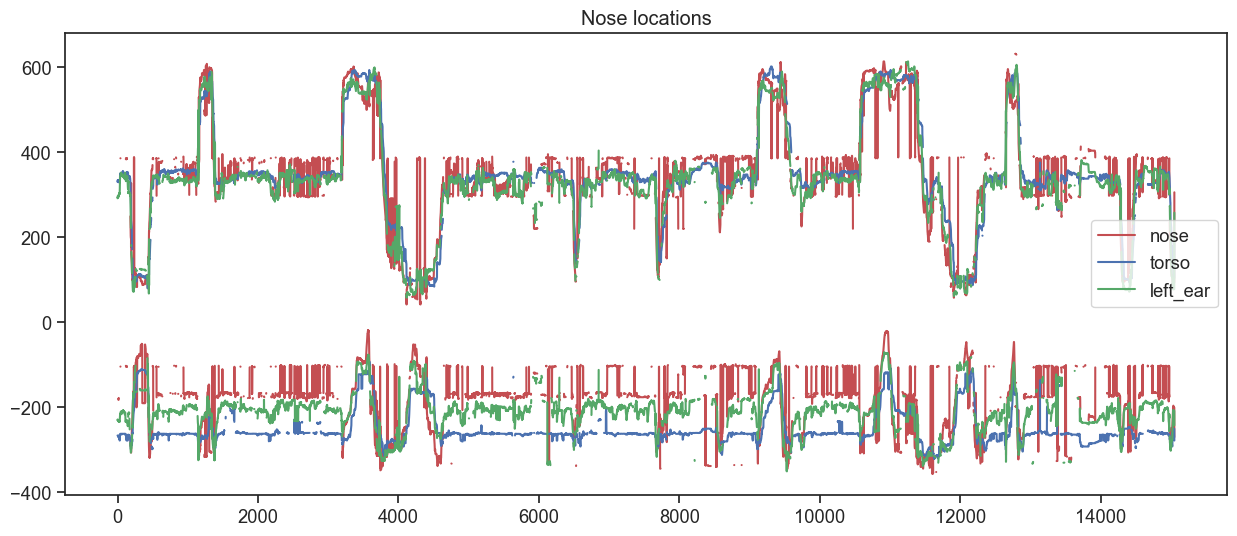

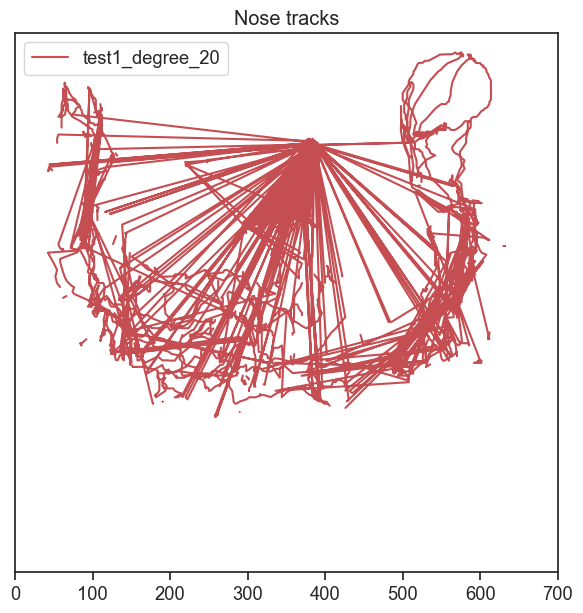

In [15]:
plt.figure()
plt.plot(nose_loc[:,0,0], 'r',label='nose')
# plt.plot(-1*nose_loc[:,1,0], 'r')
plt.plot(torso_loc[:,0,0], 'b',label='torso')
plt.plot(leftear_loc[:,0,0], 'g',label='left_ear')
# plt.plot(rightear_loc[:,0,0], 'y',label='right_ear')

plt.plot(-1*nose_loc[:,1,0], 'r')
plt.plot(-1*torso_loc[:,1,0], 'b')
plt.plot(-1*leftear_loc[:,1,0], 'g')
# plt.plot(-1*rightear_loc[:,1,0], 'y')

plt.legend(loc="center right")
plt.title('Nose locations')


plt.figure(figsize=(7,7))
plt.plot(nose_loc[:,0,0],-1*nose_loc[:,1,0], 'r',label='test1_degree_20')
# plt.plot(head_loc[:,0,0],-1*head_loc[:,1,0], 'b',label='test1_degree_20')

plt.legend()

plt.xlim(0,700)
#plt.xticks([])

plt.ylim(-500,0)
plt.yticks([])
plt.title('Nose tracks')

# color 250-450 as "interaction phase"


In [16]:
nose_vel = smooth_diff(nose_loc[:, :, 0])
torso_vel = smooth_diff(torso_loc[:,:,0])


NameError: name 'smooth_diff' is not defined

Text(0.5, 1.0, 'Velocity')

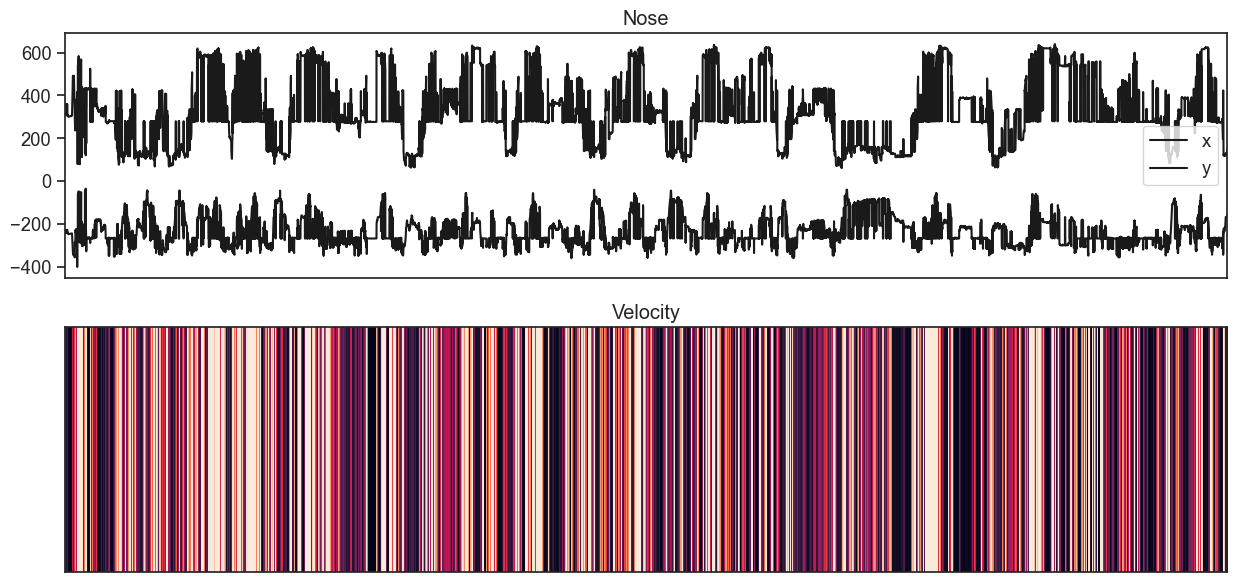

In [65]:
fig = plt.figure(figsize=(15,7))
ax1 = fig.add_subplot(211)
ax1.plot(nose_loc[:, 0, 0], 'k', label='x')
ax1.plot(-1*nose_loc[:, 1, 0], 'k', label='y')
ax1.legend()
ax1.set_xticks([])
ax1.set_title('Nose')

ax2 = fig.add_subplot(212, sharex=ax1)
ax2.imshow(nose_vel[:,np.newaxis].T, aspect='auto', vmin=0, vmax=10)
ax2.set_yticks([])
ax2.set_title('Velocity')

Text(0.5, 1.0, 'Nose tracks colored by magnitude of animal speed')

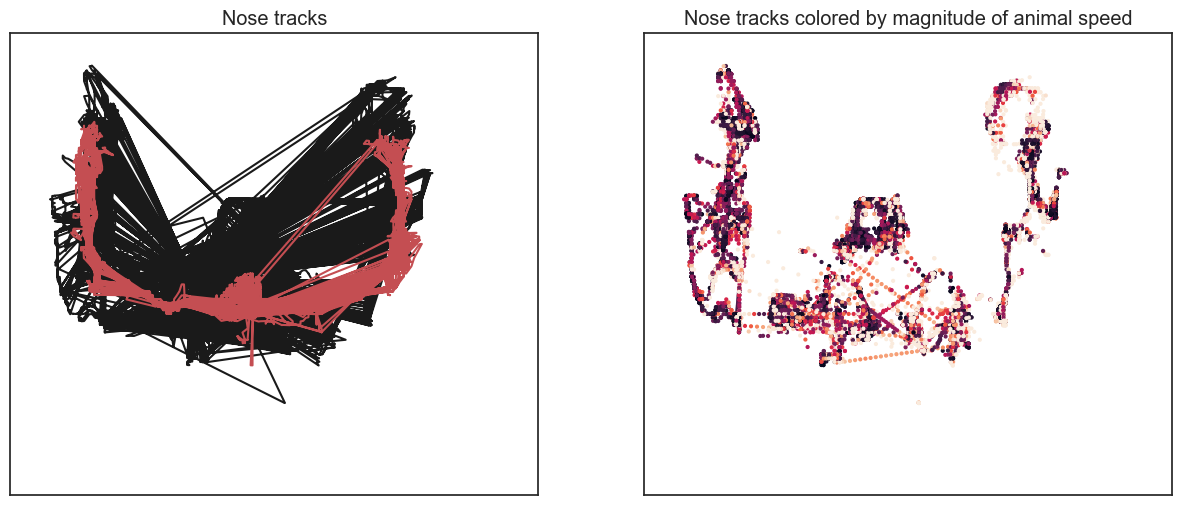

In [66]:
fig = plt.figure(figsize=(15,6))
ax1 = fig.add_subplot(121)
ax1.plot(nose_loc[:, 0, 0], -1*nose_loc[:, 1, 0], 'k')
ax1.plot(torso_loc[:, 0, 0], -1*torso_loc[:, 1, 0], 'r')
ax1.set_xlim(0,800)
ax1.set_xticks([])
ax1.set_ylim(-500,0)
ax1.set_yticks([])
ax1.set_title('Nose tracks')

kp = nose_vel  
vmin = 0
vmax = 10

ax2 = fig.add_subplot(122)
ax2.scatter(nose_loc[:,0,0], -1*nose_loc[:,1,0], c=kp, s=4, vmin=vmin, vmax=vmax)

ax2.set_xlim(0,800)
ax2.set_xticks([])
ax2.set_ylim(-500,0)
ax2.set_yticks([])
ax2.set_title('Nose tracks colored by magnitude of animal speed')


# lp = torso_vel
# ax3 = fig.add_subplot(120)
# ax3.scatter(torso_loc[:,0,0], -1*torso_loc[:,1,0], c=lp, s=4, vmin=vmin, vmax=vmax)

# ax3.set_xlim(0,800)
# ax3.set_xticks([])
# ax3.set_ylim(-500,0)
# ax3.set_yticks([])
# ax3.set_title('Torso tracks colored by magnitude of animal speed')

In [37]:
def instance_node_velocities(instance_idx):
    node_locations = locations[:, :, :, instance_idx]
    node_velocities = np.zeros((frame_count, node_count))

    for n in range(0, node_count):
        node_velocities[:, n] = smooth_diff(node_locations[:, n, :])
    
    return node_velocities

In [38]:
def plot_instance_node_velocities(instance_idx, node_velocities):
    plt.figure(figsize=(20,8))
    plt.imshow(node_velocities.T, aspect='auto', vmin=0, vmax=20, interpolation="nearest")
    plt.xlabel('frames')
    plt.ylabel('nodes')
    plt.yticks(np.arange(node_count), node_names, rotation=20);
    plt.title(f'Animal {instance_idx} node velocities')

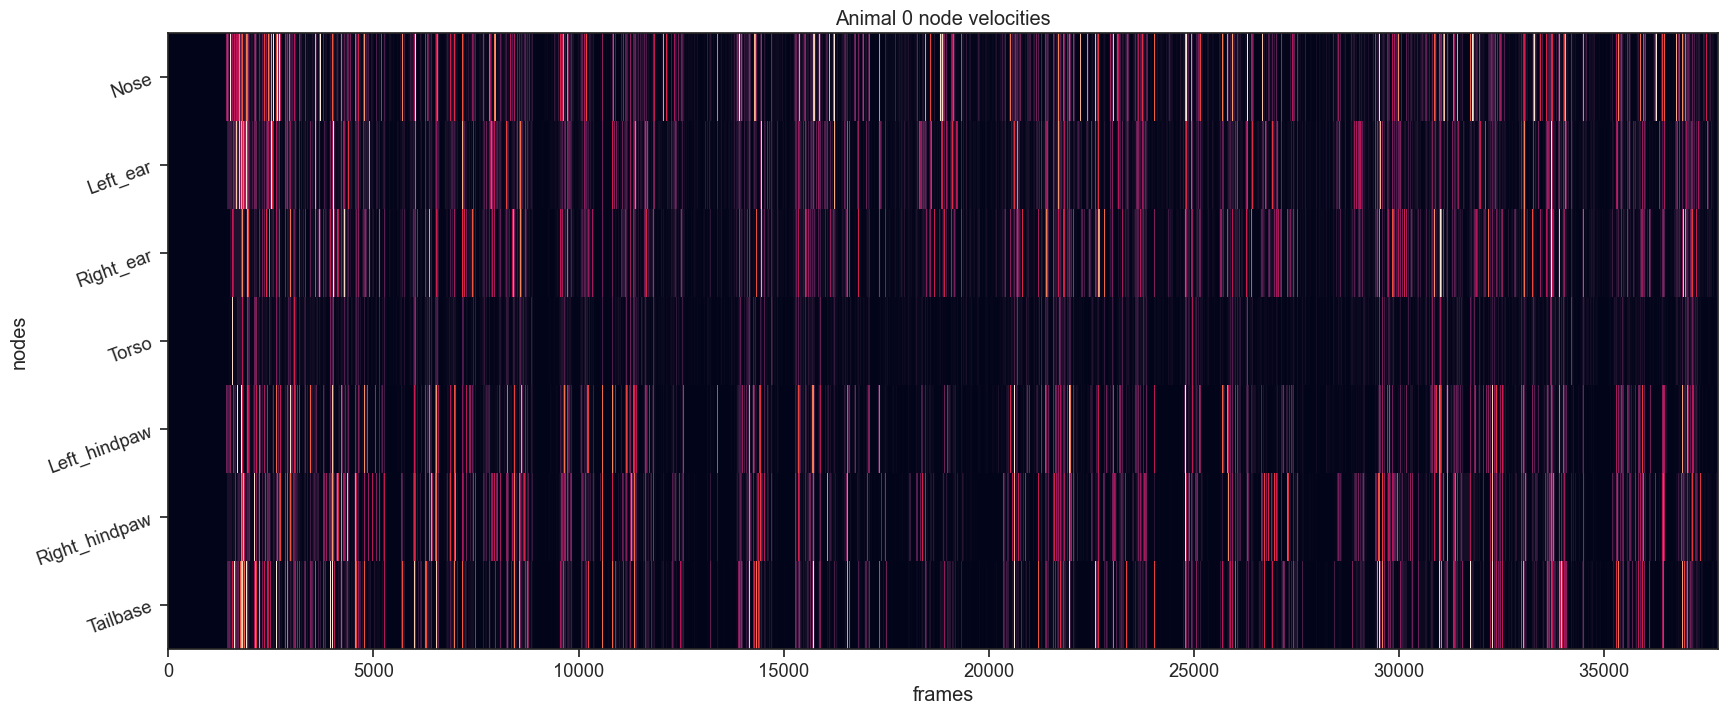

In [39]:
animal_ID = 0
node_velocities = instance_node_velocities(animal_ID)
plot_instance_node_velocities(animal_ID, node_velocities)